# 10 — Dérive de calibration : la non-stationnarité, ou la première vraie victoire de l'adaptativité

Les notebooks 08 et 09 ont établi qu'en régime **stationnaire**, un test à seuil bien
construit égale ou bat le ML. Ce notebook introduit ce que tout instrumentiste connaît :
**le gain d'une chaîne de mesure dérive** — cycles thermiques orbitaux (jour/nuit d'un
satellite), vieillissement des photodiodes, fluctuation de la puissance du laser de
lecture. Un seuil calibré au sol à t₀ ment en vol à t₀ + 6 mois.

### Le modèle

$$g(t) = A\sin\!\left(\frac{2\pi t}{T}\right), \qquad
\hat{c}_i(t) = \big(1 + g(t)\big)\,c_i + \varepsilon_i, \qquad
\varepsilon_i \sim \mathcal{N}\!\big(0, \sigma^2\big)$$

**Lecture** : « g de t égale A sinus de deux pi t sur T » — un gain qui oscille
lentement (T = 2000 acquisitions, A = 8 %) ; « c-i-chapeau égale un plus g de t, fois
c-i, plus le bruit de grenaille ». Conséquence : $\|\hat{\psi}\|^2 \approx (1+g(t))^2\|\psi\|^2$,
et un état parfaitement valide lu au sommet de la dérive affiche une norme de
$(1.08)^2 \approx 1.17$ — très au-delà de la bande de validité ±0.05. **Le seuil fixe est
structurellement condamné.**

### Les cinq candidats en compétition

1. **Seuil fixe** (le champion des notebooks 08-09) ;
2. **Recalibration en ligne** — la réponse métier : médiane glissante de ‖ψ̂‖² comme
   estimateur local du gain, puis seuil sur la norme détendancée ;
3. **Random Forest** avec les 12 features + le temps d'acquisition ;
4. **Gradient boosting sur (norme, temps) seuls** — le ML avec la bonne représentation ;
5. **Hybride physique + ML** — RF recevant en plus la statistique recalibrée.

Comme aux notebooks précédents : expériences exécutées avant les interprétations.

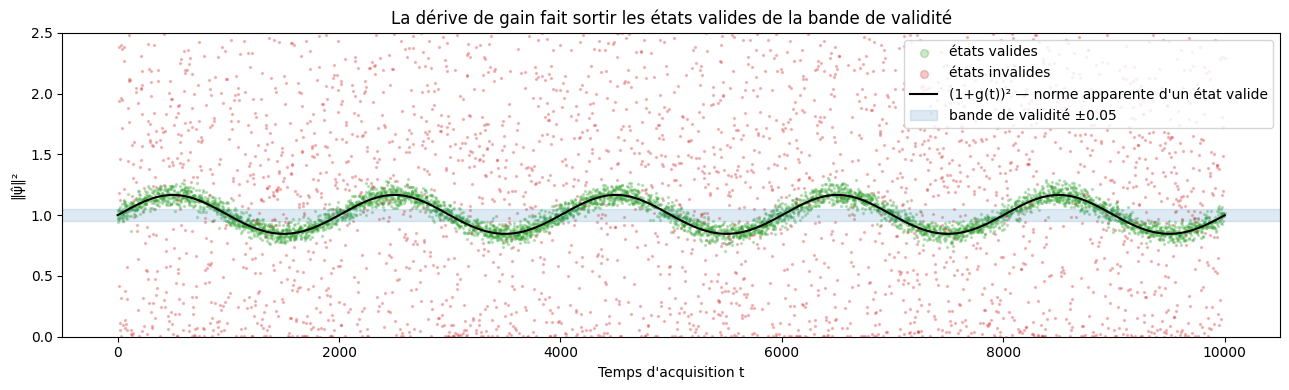

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from qsv.data_generation import create_dataset
from qsv.features import (
    add_calibration_drift,
    add_measurement_noise,
    compute_features,
    sigma_from_shots,
)

RANDOM_STATE, DIM, N = 42, 4, 500
A_DRIFT, T_DRIFT = 0.08, 2000
sigma = sigma_from_shots(N)

df = create_dataset(5000, 5000, dim=DIM, seed=RANDOM_STATE)
d = add_calibration_drift(df, n_shots=N, drift_amplitude=A_DRIFT,
                          drift_period=T_DRIFT, seed=RANDOM_STATE)
y = d["is_valid"]

fig, ax = plt.subplots(figsize=(13, 4))
t = d["acquisition_time"]
for label, color, name in [(1, "tab:green", "valides"), (0, "tab:red", "invalides")]:
    m = d["is_valid"] == label
    ax.scatter(t[m], d.loc[m, "norm_squared"], s=2, alpha=0.25, color=color, label=f"états {name}")
gain2 = (1 + A_DRIFT * np.sin(2 * np.pi * t / T_DRIFT)) ** 2
ax.plot(t, gain2, "k-", lw=1.5, label="(1+g(t))² — norme apparente d'un état valide")
ax.axhspan(0.95, 1.05, color="tab:blue", alpha=0.15, label="bande de validité ±0.05")
ax.set_ylim(0, 2.5); ax.set_xlabel("Temps d'acquisition t"); ax.set_ylabel("‖ψ̂‖²")
ax.set_title("La dérive de gain fait sortir les états valides de la bande de validité")
ax.legend(loc="upper right", markerscale=4)
plt.tight_layout(); plt.show()


La figure dit tout : la nappe verte (états valides) suit la sinusoïde du gain et
**sort périodiquement de la bande de validité**. Tout seuil fixe acceptera des invalides
proches de la courbe et rejettera des valides au sommet du cycle. Mesurons.

Seuil fixe                      : 0.9368
Recalibration en ligne          : 0.9636
RF (12 features + temps)        : 0.9388
GBM (norme + temps seuls)       : 0.9620
Hybride physique + ML           : 0.9668
(référence sans dérive, seuil fixe): 0.9724


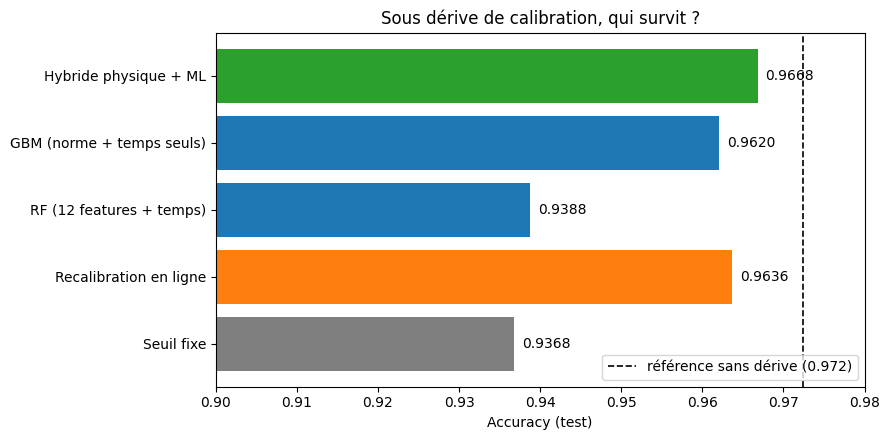

In [2]:
idx_tr, idx_te = train_test_split(np.arange(len(d)), test_size=0.25,
                                  stratify=y, random_state=RANDOM_STATE)

def stump_acc(stat, depth=2):
    s = stat.to_frame("s")
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(s.iloc[idx_tr], y.iloc[idx_tr])
    return accuracy_score(y.iloc[idx_te], m.predict(s.iloc[idx_te]))

def model_acc(model, X):
    model.fit(X.iloc[idx_tr], y.iloc[idx_tr])
    return accuracy_score(y.iloc[idx_te], model.predict(X.iloc[idx_te]))

results = {}

# 1. Seuil fixe (corrigé du biais, comme au notebook 08)
stat_fixed = np.abs(d["norm_squared"] - 1.0 - 2 * DIM * sigma**2)
results["Seuil fixe"] = stump_acc(stat_fixed)

# 2. Recalibration en ligne : médiane glissante comme estimateur local du gain²
med = d["norm_squared"].rolling(201, center=True, min_periods=50).median()
stat_recal = np.abs(d["norm_squared"] / med - 1.0)
results["Recalibration en ligne"] = stump_acc(stat_recal)

# 3. RF : 12 features + temps
feats = pd.concat([d[[c for c in d.columns if c.startswith("c")]],
                   compute_features(d, kind="all")], axis=1)
feats_t = feats.copy(); feats_t["acquisition_time"] = d["acquisition_time"]
results["RF (12 features + temps)"] = model_acc(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), feats_t)

# 4. GBM sur (norme, temps) SEULS — la bonne représentation
results["GBM (norme + temps seuls)"] = model_acc(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    d[["norm_squared", "acquisition_time"]])

# 5. Hybride : RF avec la statistique recalibrée en feature
feats_h = feats_t.copy(); feats_h["norm_recalibrated"] = stat_recal
results["Hybride physique + ML"] = model_acc(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), feats_h)

# Référence : même bruit SANS dérive
d0 = add_measurement_noise(df, n_shots=N, seed=RANDOM_STATE)
s0 = np.abs(d0["norm_squared"] - 1.0 - 2 * DIM * sigma**2).to_frame("s")
m0 = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
m0.fit(s0.iloc[idx_tr], y.iloc[idx_tr])
ref = accuracy_score(y.iloc[idx_te], m0.predict(s0.iloc[idx_te]))

for k, v in results.items():
    print(f"{k:32s}: {v:.4f}")
print(f"{'(référence sans dérive, seuil fixe)':32s}: {ref:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
names = list(results)
vals = [results[k] for k in names]
colors = ["tab:gray", "tab:orange", "tab:blue", "tab:blue", "tab:green"]
ax.barh(names, vals, color=colors)
ax.axvline(ref, color="k", ls="--", lw=1.2, label=f"référence sans dérive ({ref:.3f})")
ax.set_xlim(0.90, 0.98); ax.set_xlabel("Accuracy (test)")
ax.set_title("Sous dérive de calibration, qui survit ?")
for i, v in enumerate(vals):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=10)
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## Verdict — quatre enseignements, du plus attendu au plus subtil

1. **La non-stationnarité casse le seuil fixe** (0.972 → 0.937) : première défaite du
   champion des notebooks 08-09. C'est le résultat attendu — un instrument dont le gain
   dérive de ±8 % ne peut pas être qualifié par une constante.

2. **La réponse métier tient son rang** : la recalibration en ligne (médiane glissante,
   zéro apprentissage, une fenêtre) récupère l'essentiel (0.964). C'est ce que font
   réellement les systèmes embarqués : recalibration périodique, pas modèle appris.
   Subtilité : la médiane fonctionne ici parce que ~50 % des états de chaque fenêtre
   sont valides et forment un cluster serré à (1+g)² — l'estimateur local du gain est
   quasi non pollué par les invalides dispersés.

3. **Le ML échoue ou réussit selon la représentation — pas selon sa puissance.**
   Le RF noyé dans 12 features + temps stagne à 0.939 : l'interaction fine
   norme×temps se dilue dans les dimensions non pertinentes (malédiction des features
   inutiles). Le même problème donné à un gradient boosting sur **(norme, temps)
   seuls** atteint 0.962 : le modèle apprend la carte de calibration g(t) — c'est la
   version apprise de la courbe noire de la première figure. Troisième apparition de
   la même leçon depuis le notebook 08 : *la représentation prime sur l'algorithme*.

4. **Le meilleur système est hybride** (0.967) : la statistique recalibrée (physique)
   donnée en feature à la forêt (ML). La connaissance métier encode en une ligne ce que
   le modèle mettrait des milliers d'exemples à approximer ; le ML ajoute la gestion
   des cas résiduels. C'est l'architecture des vrais systèmes de qualification
   embarqués : un cœur physique calibré, une couche apprise pour les résidus.

### Lien aérospatial

Ce notebook est le modèle réduit du **cycle thermique orbital** : un satellite en orbite
basse traverse l'ombre et le soleil ~15 fois par jour, et chaque chaîne de mesure
embarquée voit son gain osciller en conséquence. Les stratégies comparées ici sont
exactement celles de l'ingénierie réelle : seuil qualifié au sol (candidat 1),
recalibration périodique en vol (candidat 2), carte de calibration apprise au sol sur
télémesures (candidat 4), architecture hybride (candidat 5). La hiérarchie mesurée ici
— métier ≈ ML bien représenté < hybride — est celle qu'on retrouve dans les systèmes
FDIR opérationnels.

### Jalon 4 : bilan

Avec les notebooks 09 et 10, le jalon 4 a répondu à sa question : **le ML gagne sa place
quand le problème est non stationnaire ou exige un diagnostic multiclasse — et il la
gagne d'autant mieux qu'il est marié à la structure physique, pas opposé à elle.**
Reste au jalon 4 : dimensions variables et abaques N ↔ taux d'erreur (voir ROADMAP).